# ROCS Implementation Comparison Viewer

This notebook analyzes and compares DrugEx reinforcement learning results across different ROCS scoring implementations:
- **CDPKit Aggregate**: Open-source aggregate ROCS
- **CDPKit Supermol**: Open-source supermolecule ROCS
- **OpenEye ROCS**: Commercial FastROCS (2 metrics)
- **RDKit Aggregate**: Open-source RDKit aggregate
- **RDKit Supermol**: Open-source RDKit supermolecule

The notebook provides comprehensive visualizations including:
- ROCS score progression over epochs
- Training metrics comparison
- Chemical space analysis (t-SNE)
- Top molecules visualization
- Statistical comparisons

In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Define the root directory path
root_directory = Path("/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rl_runs")

print(f"Root directory: {root_directory}")
print(f"Exists: {root_directory.exists()}")

Root directory: /home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/rocs_rl_ccr/rl_runs
Exists: True


## 1. Data Loading

Load data from all ROCS implementations and create unified DataFrames with standardized column names.

In [2]:
# Define ROCS implementations and their configurations
implementations = {
    'CDPKit_Aggregate': {
        'dir': 'cdpkit_aggregate',
        'rocs_col': 'CDPKit_ROCS_TanimotoCombo',
        'color': '#2E86AB',
        'label': 'CDPKit Aggregate'
    },
    'CDPKit_Supermol': {
        'dir': 'cdpkit_supermol',
        'rocs_col': 'CDPKit_ROCS_Supermol_TanimotoCombo',
        'color': '#A23B72',
        'label': 'CDPKit Supermol'
    },
    'OpenEye_ROCS': {
        'dir': 'openeye_rocs',
        'rocs_col': 'ROCS_CCR2_SDF',  # Primary metric
        'rocs_col_secondary': 'ROCS_Model3-4_SQ',  # Secondary metric
        'color': '#F18F01',
        'label': 'OpenEye ROCS'
    },
    'RDKit_Aggregate': {
        'dir': 'rdkit_aggregate',
        'rocs_col': 'RDKit_Aggregate_TanimotoCombo',
        'color': '#C73E1D',
        'label': 'RDKit Aggregate'
    },
    'RDKit_Supermol': {
        'dir': 'rdkit_supermol',
        'rocs_col': 'RDKit_Supermolecule_TanimotoCombo',
        'color': '#6A994E',
        'label': 'RDKit Supermol'
    }
}

print("ROCS Implementations:")
for impl_id, config in implementations.items():
    print(f"  - {config['label']} ({impl_id})")

ROCS Implementations:
  - CDPKit Aggregate (CDPKit_Aggregate)
  - CDPKit Supermol (CDPKit_Supermol)
  - OpenEye ROCS (OpenEye_ROCS)
  - RDKit Aggregate (RDKit_Aggregate)
  - RDKit Supermol (RDKit_Supermol)


In [3]:
# Load all data
smiles_dataframes = []
fit_dataframes = []

for impl_id, config in implementations.items():
    impl_dir = root_directory / config['dir']
    
    # Construct file paths
    smiles_file = impl_dir / f"{config['dir']}_smiles.tsv"
    fit_file = impl_dir / f"{config['dir']}_fit.tsv"
    
    if smiles_file.exists() and fit_file.exists():
        # Load SMILES data
        df_smiles = pd.read_csv(smiles_file, sep='\t')
        df_smiles['Implementation'] = impl_id
        df_smiles['Implementation_Label'] = config['label']
        
        # Standardize ROCS column name
        df_smiles['ROCS_Score'] = df_smiles[config['rocs_col']]
        
        # For OpenEye, also keep secondary metric
        if 'rocs_col_secondary' in config:
            df_smiles['ROCS_Score_Secondary'] = df_smiles[config['rocs_col_secondary']]
        
        smiles_dataframes.append(df_smiles)
        
        # Load fit data
        df_fit = pd.read_csv(fit_file, sep='\t')
        df_fit['Implementation'] = impl_id
        df_fit['Implementation_Label'] = config['label']
        fit_dataframes.append(df_fit)
        
        print(f"✓ Loaded {impl_id}: {len(df_smiles)} SMILES, {len(df_fit)} epochs")
    else:
        print(f"✗ Missing files for {impl_id}")

# Concatenate all dataframes
combined_smiles_df = pd.concat(smiles_dataframes, ignore_index=True)
combined_fit_df = pd.concat(fit_dataframes, ignore_index=True)

print(f"\nTotal combined SMILES: {len(combined_smiles_df)}")
print(f"Total combined fit records: {len(combined_fit_df)}")
print(f"\nCombined SMILES columns: {list(combined_smiles_df.columns)}")
print(f"Combined fit columns: {list(combined_fit_df.columns)}")

✓ Loaded CDPKit_Aggregate: 3000 SMILES, 30 epochs
✓ Loaded CDPKit_Supermol: 3000 SMILES, 30 epochs
✓ Loaded OpenEye_ROCS: 3000 SMILES, 30 epochs
✓ Loaded RDKit_Aggregate: 3000 SMILES, 30 epochs
✓ Loaded RDKit_Supermol: 3000 SMILES, 30 epochs

Total combined SMILES: 15000
Total combined fit records: 150

Combined SMILES columns: ['Epoch', 'SMILES', 'Valid', 'Desired', 'CDPKit_ROCS_TanimotoCombo', 'SA', 'Implementation', 'Implementation_Label', 'ROCS_Score', 'CDPKit_ROCS_Supermol_TanimotoCombo', 'ROCS_CCR2_SDF', 'ROCS_Model3-4_SQ', 'ROCS_Score_Secondary', 'RDKit_Aggregate_TanimotoCombo', 'RDKit_Supermolecule_TanimotoCombo']
Combined fit columns: ['Epoch', 'valid_ratio', 'unique_ratio', 'desired_ratio', 'avg_amean', 'avg_gmean', 'loss_train', 'best_epoch', 'Implementation', 'Implementation_Label']


In [4]:
# Display summary statistics
print("=" * 80)
print("DATA SUMMARY")
print("=" * 80)

for impl_id, config in implementations.items():
    impl_data = combined_smiles_df[combined_smiles_df['Implementation'] == impl_id]
    impl_fit = combined_fit_df[combined_fit_df['Implementation'] == impl_id]
    
    print(f"\n{config['label']}:")
    print(f"  Molecules: {len(impl_data)}")
    print(f"  Epochs: {len(impl_fit)}")
    print(f"  ROCS Score: {impl_data['ROCS_Score'].mean():.3f} ± {impl_data['ROCS_Score'].std():.3f}")
    print(f"  SA Score: {impl_data['SA'].mean():.3f} ± {impl_data['SA'].std():.3f}")
    print(f"  Valid Ratio (final): {impl_fit['valid_ratio'].iloc[-1]:.3f}")
    print(f"  Desired Ratio (final): {impl_fit['desired_ratio'].iloc[-1]:.3f}")
    print(f"  Best Epoch: {impl_fit['best_epoch'].max()}")

DATA SUMMARY

CDPKit Aggregate:
  Molecules: 3000
  Epochs: 30
  ROCS Score: 0.656 ± 0.264
  SA Score: 0.886 ± 0.242
  Valid Ratio (final): 0.970
  Desired Ratio (final): 0.920
  Best Epoch: 25

CDPKit Supermol:
  Molecules: 3000
  Epochs: 30
  ROCS Score: 0.146 ± 0.100
  SA Score: 0.872 ± 0.263
  Valid Ratio (final): 0.890
  Desired Ratio (final): 0.140
  Best Epoch: 29

OpenEye ROCS:
  Molecules: 3000
  Epochs: 30
  ROCS Score: 0.820 ± 0.280
  SA Score: 0.883 ± 0.246
  Valid Ratio (final): 0.940
  Desired Ratio (final): 0.290
  Best Epoch: 30

RDKit Aggregate:
  Molecules: 3000
  Epochs: 30
  ROCS Score: 0.771 ± 0.281
  SA Score: 0.881 ± 0.253
  Valid Ratio (final): 0.930
  Desired Ratio (final): 0.920
  Best Epoch: 19

RDKit Supermol:
  Molecules: 3000
  Epochs: 30
  ROCS Score: 0.211 ± 0.135
  SA Score: 0.876 ± 0.258
  Valid Ratio (final): 0.960
  Desired Ratio (final): 0.470
  Best Epoch: 22


## 2. ROCS Score Comparison

Compare ROCS score progression across implementations during training.

In [5]:
# Calculate average ROCS per epoch for each implementation
average_rocs_per_epoch = combined_smiles_df.groupby(['Implementation', 'Implementation_Label', 'Epoch'])['ROCS_Score'].agg(['mean', 'std', 'min', 'max']).reset_index()

print("Average ROCS per Epoch:")
print(average_rocs_per_epoch.head(20))

Average ROCS per Epoch:
      Implementation Implementation_Label  Epoch     mean       std  min  \
0   CDPKit_Aggregate     CDPKit Aggregate      1  0.61156  0.264402  0.0   
1   CDPKit_Aggregate     CDPKit Aggregate      2  0.68495  0.251241  0.0   
2   CDPKit_Aggregate     CDPKit Aggregate      3  0.63036  0.276048  0.0   
3   CDPKit_Aggregate     CDPKit Aggregate      4  0.68153  0.258743  0.0   
4   CDPKit_Aggregate     CDPKit Aggregate      5  0.66483  0.253136  0.0   
5   CDPKit_Aggregate     CDPKit Aggregate      6  0.65351  0.240461  0.0   
6   CDPKit_Aggregate     CDPKit Aggregate      7  0.65255  0.260202  0.0   
7   CDPKit_Aggregate     CDPKit Aggregate      8  0.64465  0.274580  0.0   
8   CDPKit_Aggregate     CDPKit Aggregate      9  0.64518  0.287413  0.0   
9   CDPKit_Aggregate     CDPKit Aggregate     10  0.57551  0.291241  0.0   
10  CDPKit_Aggregate     CDPKit Aggregate     11  0.64218  0.266649  0.0   
11  CDPKit_Aggregate     CDPKit Aggregate     12  0.65532  0.278

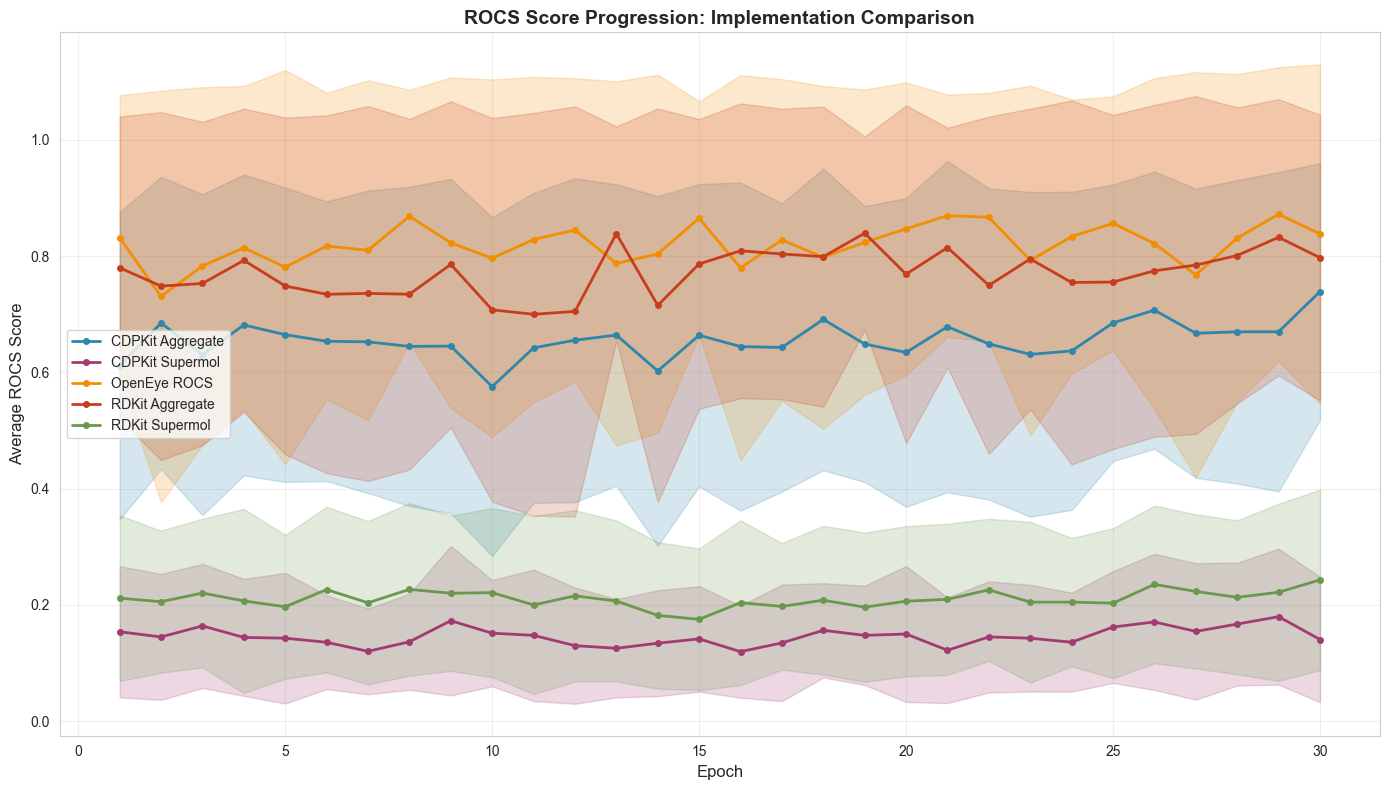

In [6]:
# Plot: Average ROCS per epoch for all implementations
plt.figure(figsize=(14, 8))

for impl_id, config in implementations.items():
    impl_data = average_rocs_per_epoch[average_rocs_per_epoch['Implementation'] == impl_id]
    plt.plot(impl_data['Epoch'], impl_data['mean'], 
             label=config['label'], color=config['color'], linewidth=2, marker='o', markersize=4)
    
    # Add standard deviation as shaded area
    plt.fill_between(impl_data['Epoch'], 
                     impl_data['mean'] - impl_data['std'], 
                     impl_data['mean'] + impl_data['std'], 
                     alpha=0.2, color=config['color'])

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average ROCS Score', fontsize=12)
plt.title('ROCS Score Progression: Implementation Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2117925/380570280.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(final_epoch_data, labels=labels, patch_artist=True)
/tmp/ipykernel_2117925/380570280.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=final_df, x='Implementation_Label', y='ROCS_Score',


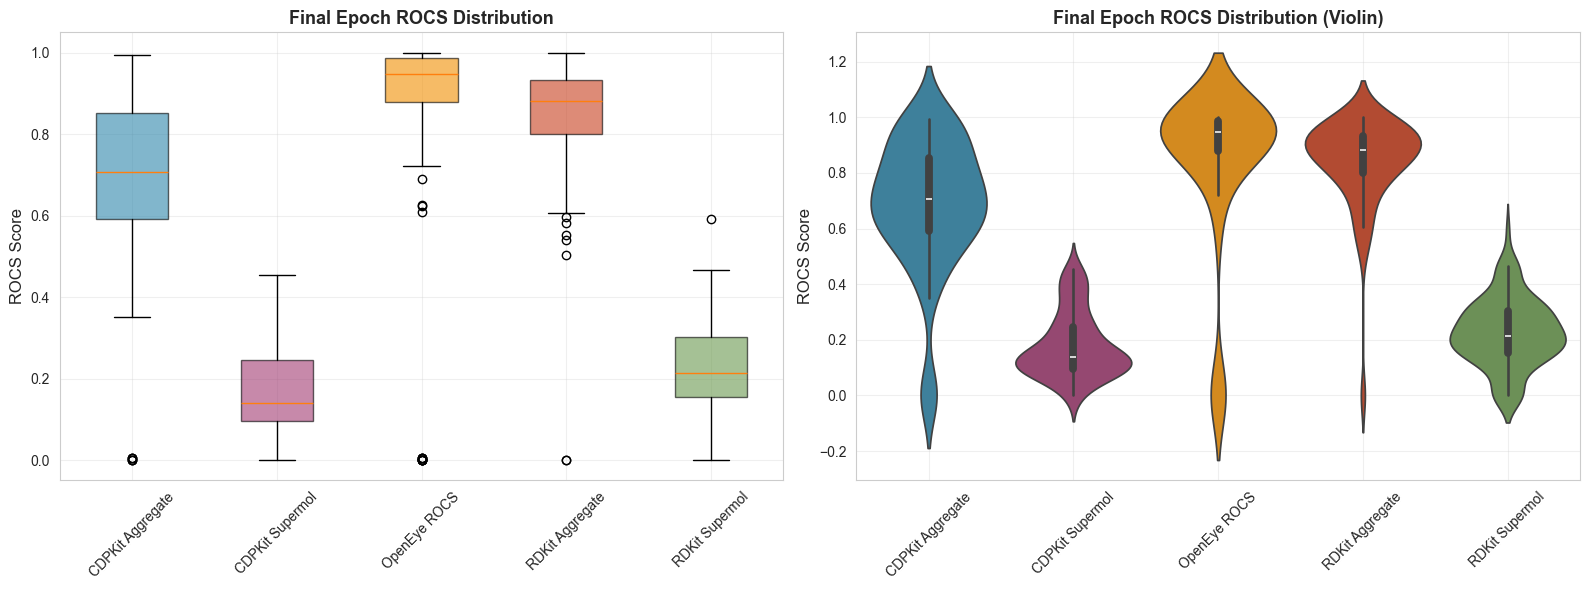

In [7]:
# Plot: Final epoch ROCS distribution comparison
final_epochs = {}
for impl_id in implementations.keys():
    impl_fit = combined_fit_df[combined_fit_df['Implementation'] == impl_id]
    final_epochs[impl_id] = impl_fit['best_epoch'].max()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
final_epoch_data = []
labels = []
colors = []

for impl_id, config in implementations.items():
    impl_data = combined_smiles_df[
        (combined_smiles_df['Implementation'] == impl_id) & 
        (combined_smiles_df['Epoch'] == final_epochs[impl_id])
    ]
    final_epoch_data.append(impl_data['ROCS_Score'].values)
    labels.append(config['label'])
    colors.append(config['color'])

bp = axes[0].boxplot(final_epoch_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0].set_ylabel('ROCS Score', fontsize=12)
axes[0].set_title('Final Epoch ROCS Distribution', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Violin plot
final_df = pd.concat([
    combined_smiles_df[
        (combined_smiles_df['Implementation'] == impl_id) & 
        (combined_smiles_df['Epoch'] == final_epochs[impl_id])
    ] for impl_id in implementations.keys()
])

sns.violinplot(data=final_df, x='Implementation_Label', y='ROCS_Score', 
               palette=[config['color'] for config in implementations.values()],
               ax=axes[1])
axes[1].set_ylabel('ROCS Score', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_title('Final Epoch ROCS Distribution (Violin)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

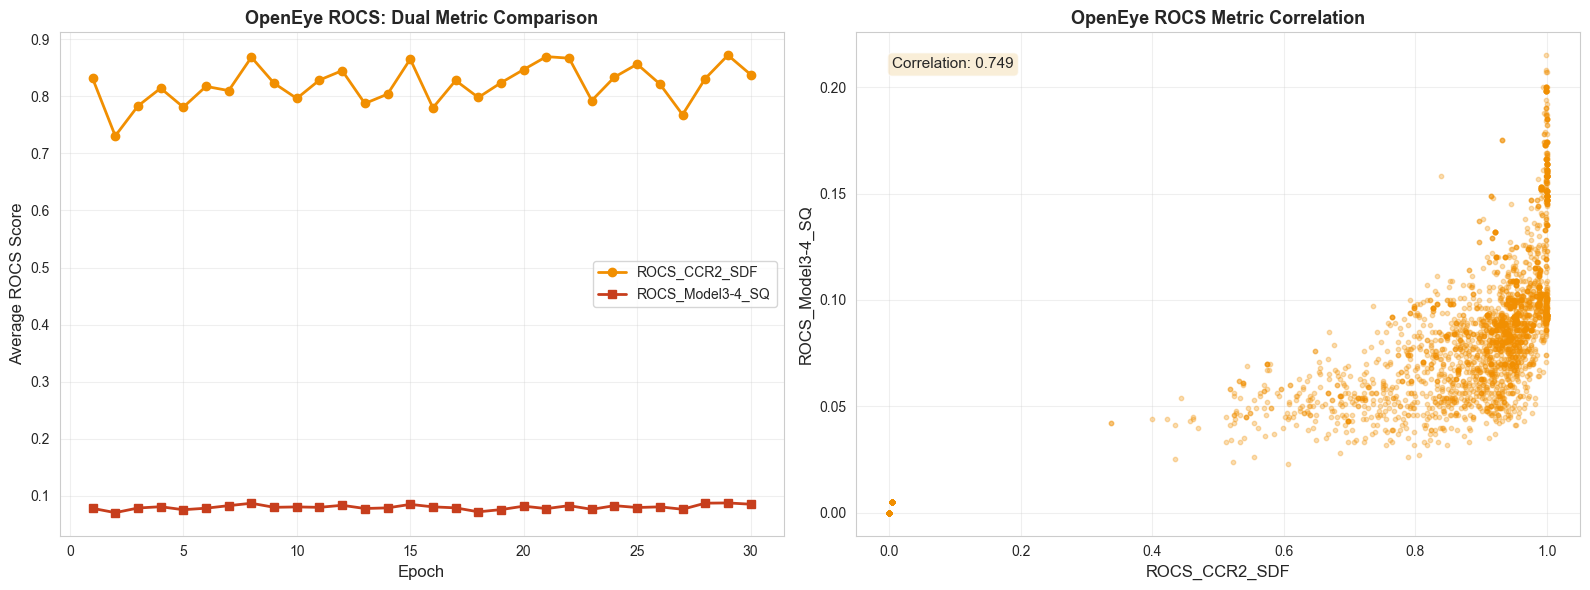

In [8]:
# OpenEye dual metric comparison (if available)
if 'OpenEye_ROCS' in implementations and 'ROCS_Score_Secondary' in combined_smiles_df.columns:
    openeye_data = combined_smiles_df[combined_smiles_df['Implementation'] == 'OpenEye_ROCS']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Progression comparison
    openeye_by_epoch = openeye_data.groupby('Epoch').agg({
        'ROCS_Score': 'mean',
        'ROCS_Score_Secondary': 'mean'
    }).reset_index()
    
    axes[0].plot(openeye_by_epoch['Epoch'], openeye_by_epoch['ROCS_Score'], 
                label='ROCS_CCR2_SDF', color='#F18F01', linewidth=2, marker='o')
    axes[0].plot(openeye_by_epoch['Epoch'], openeye_by_epoch['ROCS_Score_Secondary'], 
                label='ROCS_Model3-4_SQ', color='#C73E1D', linewidth=2, marker='s')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Average ROCS Score', fontsize=12)
    axes[0].set_title('OpenEye ROCS: Dual Metric Comparison', fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Correlation plot
    axes[1].scatter(openeye_data['ROCS_Score'], openeye_data['ROCS_Score_Secondary'], 
                   alpha=0.3, color='#F18F01', s=10)
    axes[1].set_xlabel('ROCS_CCR2_SDF', fontsize=12)
    axes[1].set_ylabel('ROCS_Model3-4_SQ', fontsize=12)
    axes[1].set_title('OpenEye ROCS Metric Correlation', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = openeye_data[['ROCS_Score', 'ROCS_Score_Secondary']].corr().iloc[0, 1]
    axes[1].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                transform=axes[1].transAxes, fontsize=11,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
else:
    print("OpenEye ROCS dual metric not available or not loaded")

## 3. Training Metrics Dashboard

Compare training dynamics across implementations.

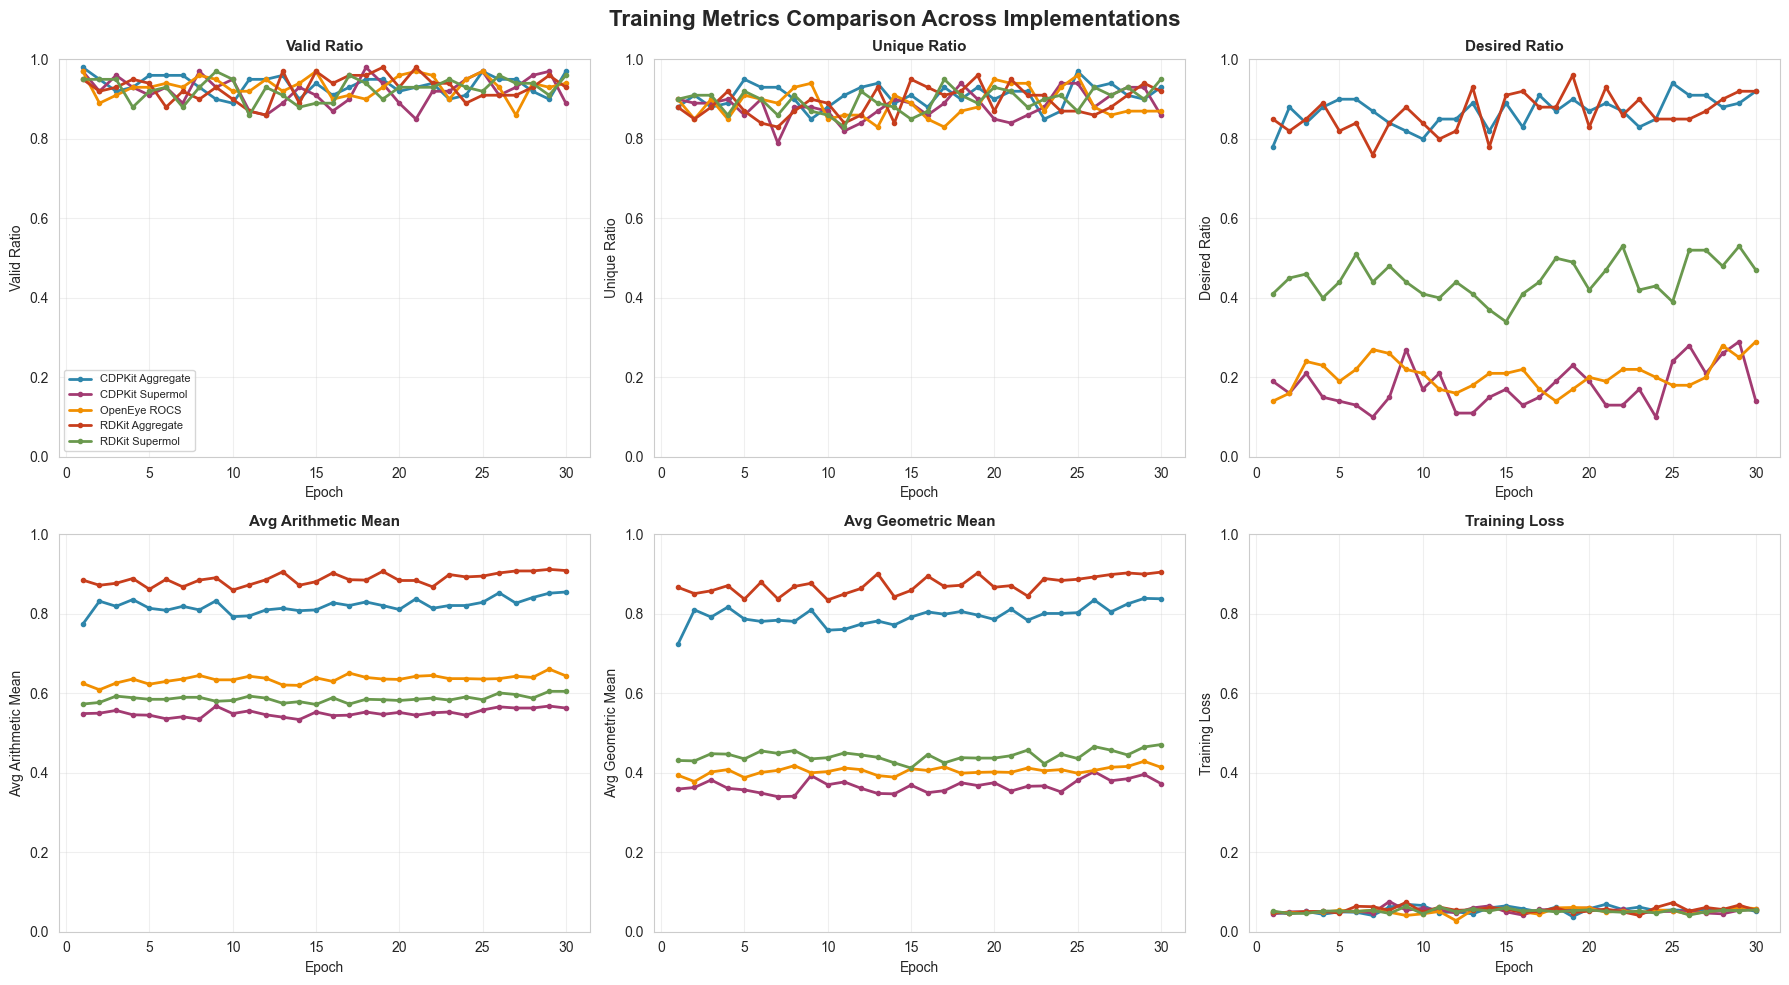

In [9]:
# Multi-panel training metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Metrics Comparison Across Implementations', fontsize=16, fontweight='bold')

metrics = [
    ('valid_ratio', 'Valid Ratio'),
    ('unique_ratio', 'Unique Ratio'),
    ('desired_ratio', 'Desired Ratio'),
    ('avg_amean', 'Avg Arithmetic Mean'),
    ('avg_gmean', 'Avg Geometric Mean'),
    ('loss_train', 'Training Loss')
]

for idx, (metric, title) in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    for impl_id, config in implementations.items():
        impl_data = combined_fit_df[combined_fit_df['Implementation'] == impl_id]
        ax.plot(impl_data['Epoch'], impl_data[metric], 
               label=config['label'], color=config['color'], linewidth=2, marker='o', markersize=3)
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)  # Set y-axis range to 0-1 for all plots
    
    if idx == 0:  # Add legend only to first subplot
        ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
# Convergence analysis - Best epoch comparison
convergence_data = []

for impl_id, config in implementations.items():
    impl_fit = combined_fit_df[combined_fit_df['Implementation'] == impl_id]
    best_epoch = impl_fit['best_epoch'].max()
    best_epoch_row = impl_fit[impl_fit['Epoch'] == best_epoch].iloc[0]
    
    convergence_data.append({
        'Implementation': config['label'],
        'Best Epoch': best_epoch,
        'Desired Ratio': best_epoch_row['desired_ratio'],
        'Avg Arithmetic Mean': best_epoch_row['avg_amean'],
        'Avg Geometric Mean': best_epoch_row['avg_gmean']
    })

convergence_df = pd.DataFrame(convergence_data)
print("\nConvergence Analysis - Best Epoch Metrics:")
print(convergence_df.to_string(index=False))


Convergence Analysis - Best Epoch Metrics:
  Implementation  Best Epoch  Desired Ratio  Avg Arithmetic Mean  Avg Geometric Mean
CDPKit Aggregate          25           0.94                0.829               0.803
 CDPKit Supermol          29           0.29                0.568               0.396
    OpenEye ROCS          30           0.29                0.644               0.414
 RDKit Aggregate          19           0.96                0.907               0.903
  RDKit Supermol          22           0.53                0.588               0.457


## 4. Chemical Space Analysis (t-SNE)

Visualize chemical space coverage using t-SNE dimensionality reduction with Morgan fingerprints.

In [11]:
# Import libraries for chemical space analysis
from sklearn.manifold import TSNE
from qsprpred.data.descriptors.fingerprints import MorganFP
from qsprpred.data.tables.mol import MoleculeTable

print("Preparing data for t-SNE analysis...")

# Get best epoch molecules for each implementation
best_epoch_molecules = []

for impl_id, config in implementations.items():
    impl_fit = combined_fit_df[combined_fit_df['Implementation'] == impl_id]
    best_epoch = impl_fit['best_epoch'].max()
    
    impl_best = combined_smiles_df[
        (combined_smiles_df['Implementation'] == impl_id) & 
        (combined_smiles_df['Epoch'] == best_epoch)
    ].copy()
    
    best_epoch_molecules.append(impl_best)
    print(f"  {config['label']}: {len(impl_best)} molecules at epoch {best_epoch}")

best_epoch_df = pd.concat(best_epoch_molecules, ignore_index=True)
print(f"\nTotal molecules for t-SNE: {len(best_epoch_df)}")

Preparing data for t-SNE analysis...
  CDPKit Aggregate: 100 molecules at epoch 25
  CDPKit Supermol: 100 molecules at epoch 29
  OpenEye ROCS: 100 molecules at epoch 30
  RDKit Aggregate: 100 molecules at epoch 19
  RDKit Supermol: 100 molecules at epoch 22

Total molecules for t-SNE: 500


In [12]:
# Calculate Morgan fingerprints and perform t-SNE
print("Calculating Morgan fingerprints...")
dataset = MoleculeTable('ROCS_Comparison', best_epoch_df, overwrite=True)
dataset.addDescriptors([MorganFP(radius=3, nBits=2048)], recalculate=False)

print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_data = tsne.fit_transform(dataset.getDescriptors())

# Add t-SNE coordinates to dataset
dataset.addProperty("TSNE_1", tsne_data[:, 0])
dataset.addProperty("TSNE_2", tsne_data[:, 1])

tsne_df = dataset.getDF()
print("t-SNE complete!")

qsprpred - WARNING - Dropped 21 invalid molecules from the data set.


Calculating Morgan fingerprints...
Performing t-SNE dimensionality reduction...
t-SNE complete!


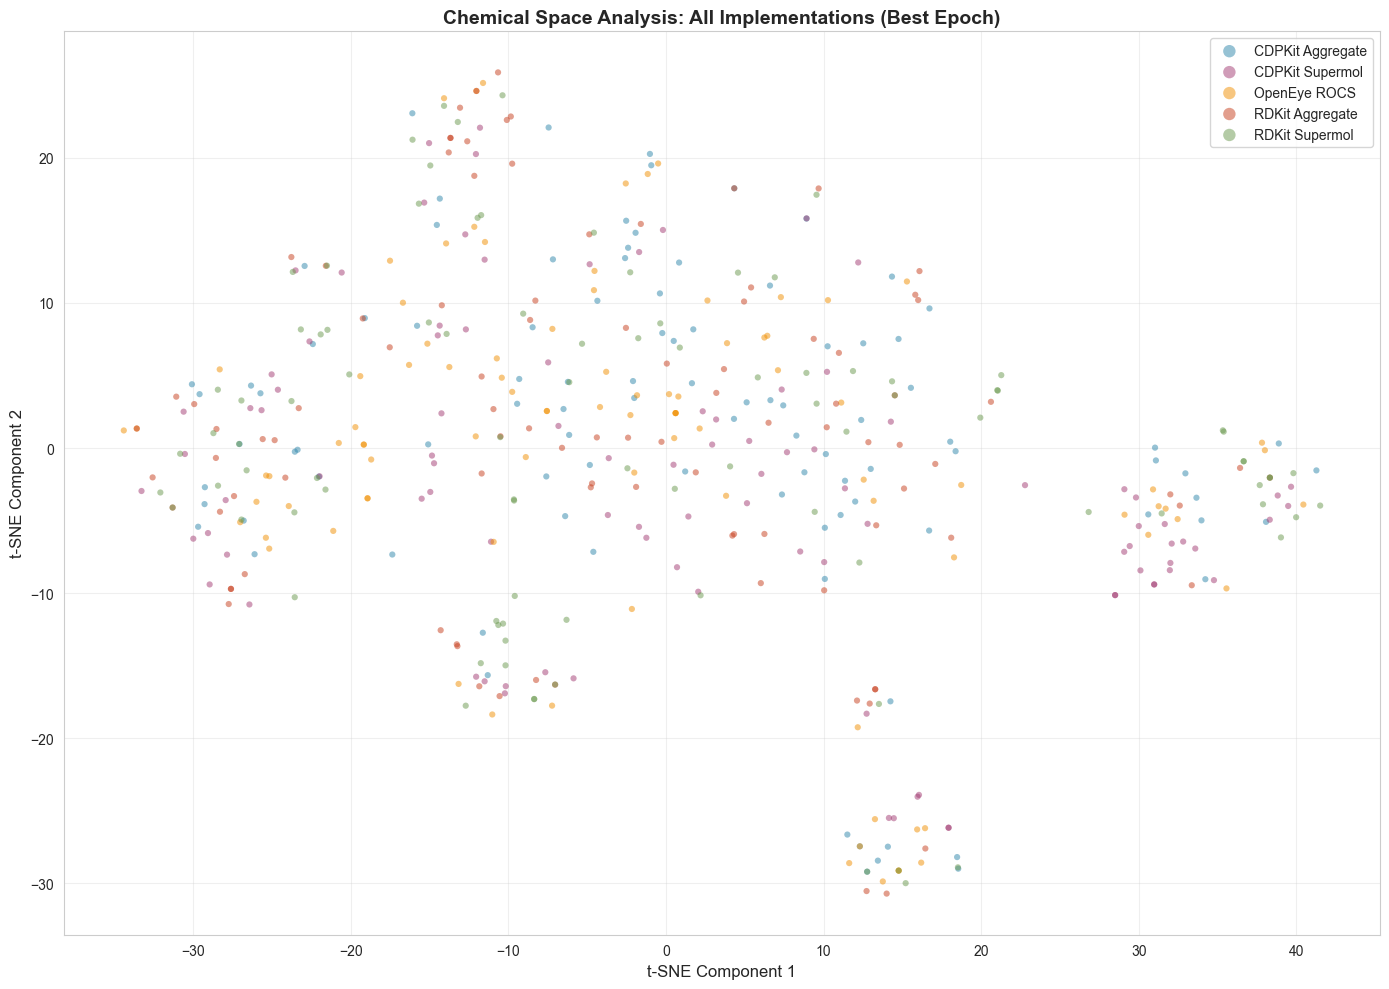

In [13]:
# Plot: Combined t-SNE colored by implementation
plt.figure(figsize=(14, 10))

for impl_id, config in implementations.items():
    impl_tsne = tsne_df[tsne_df['Implementation'] == impl_id]
    plt.scatter(impl_tsne['TSNE_1'], impl_tsne['TSNE_2'], 
               c=config['color'], label=config['label'], 
               alpha=0.5, s=20, edgecolors='none')

plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('Chemical Space Analysis: All Implementations (Best Epoch)', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10, markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

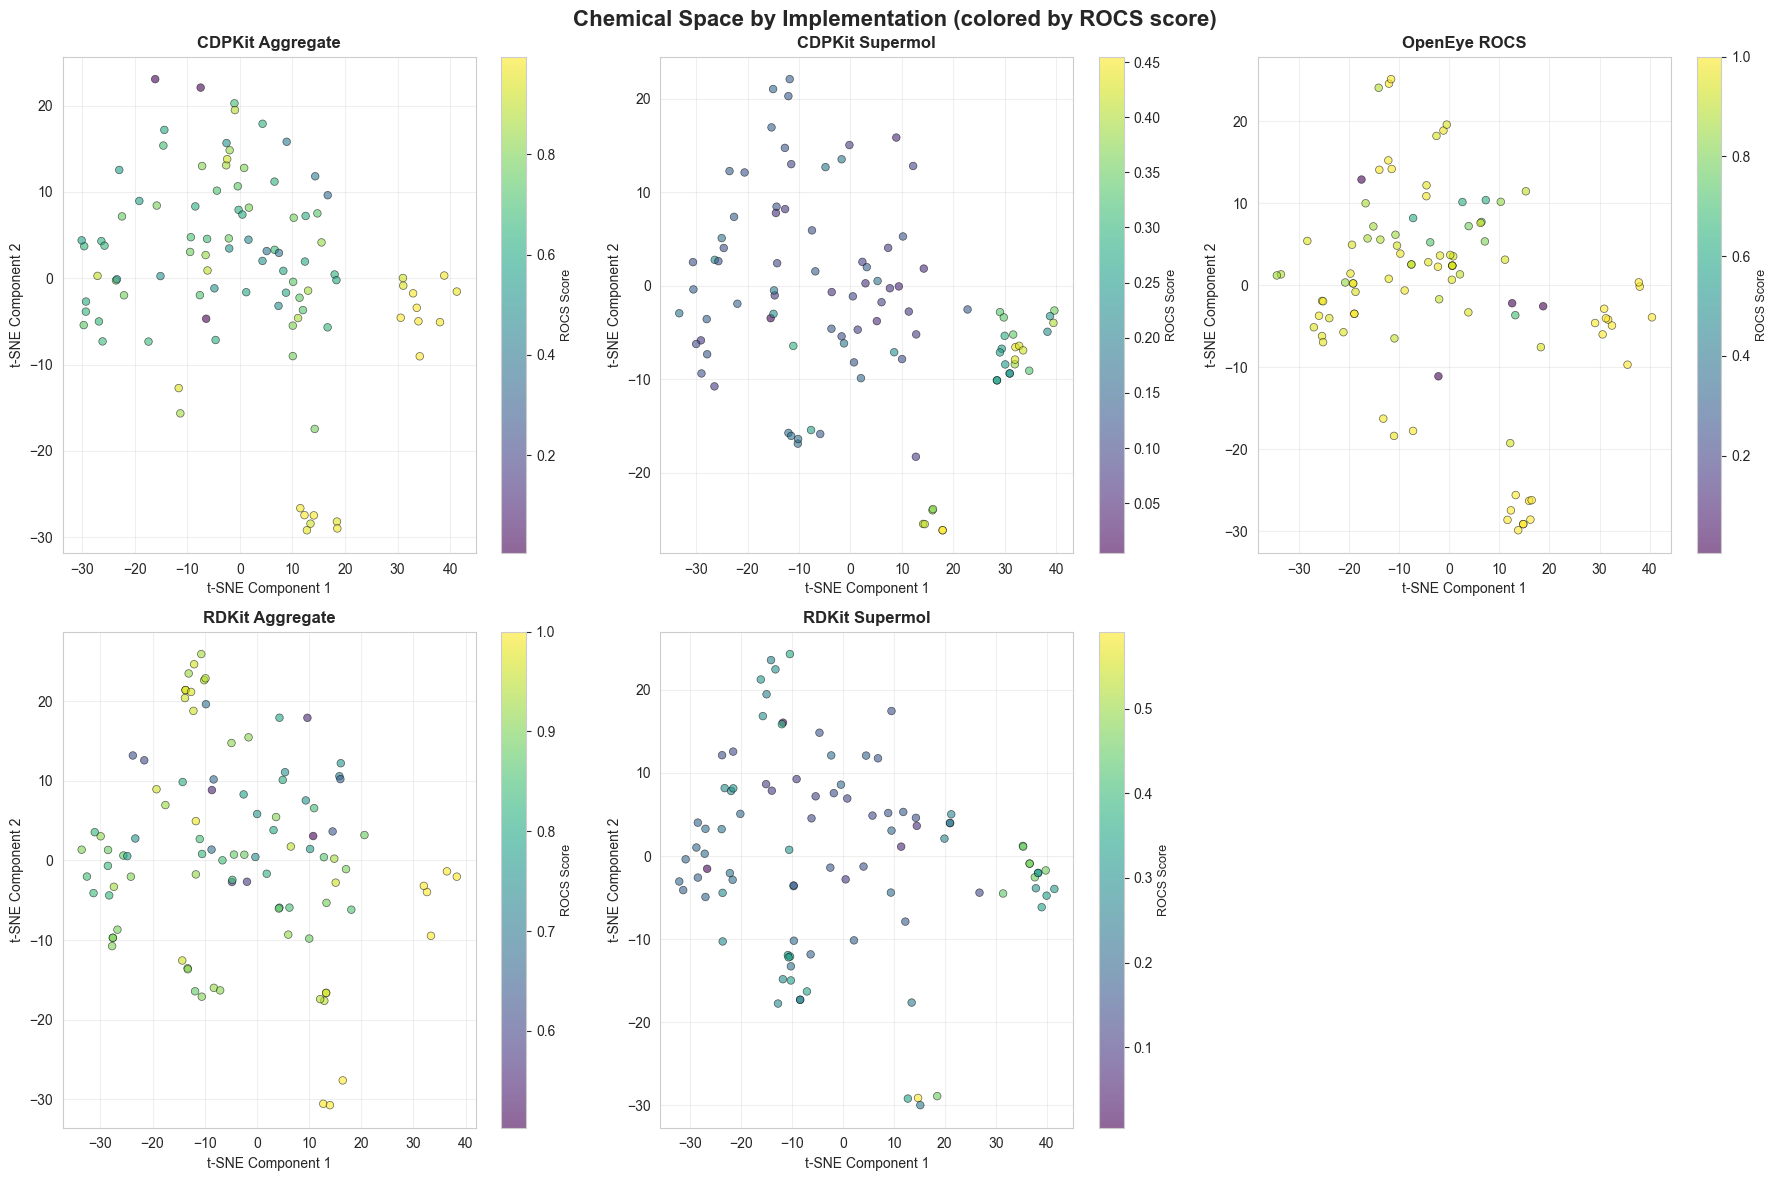

In [14]:
# Plot: Individual t-SNE plots colored by ROCS score
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Chemical Space by Implementation (colored by ROCS score)', fontsize=16, fontweight='bold')

for idx, (impl_id, config) in enumerate(implementations.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    impl_tsne = tsne_df[tsne_df['Implementation'] == impl_id]
    
    scatter = ax.scatter(impl_tsne['TSNE_1'], impl_tsne['TSNE_2'], 
                        c=impl_tsne['ROCS_Score'], cmap='viridis', 
                        alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('t-SNE Component 1', fontsize=10)
    ax.set_ylabel('t-SNE Component 2', fontsize=10)
    ax.set_title(config['label'], fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('ROCS Score', fontsize=9)

# Hide the 6th subplot (we only have 5 implementations)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 5. Top Molecules Visualization

Interactive visualization of top-scoring molecules from each implementation using mols2grid.

In [15]:
import mols2grid
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

print("Preparing interactive molecule viewer with dataset switching...")

best_epochs = combined_fit_df.groupby("Implementation")["best_epoch"].max()

top_molecules = {}
for impl_id in implementations:
    epoch = best_epochs.get(impl_id)
    if pd.isna(epoch):
        continue
    mask = (
        (combined_smiles_df["Implementation"] == impl_id)
        & (combined_smiles_df["Epoch"] == epoch)
    )
    top_molecules[impl_id] = combined_smiles_df.loc[mask].nlargest(50, "ROCS_Score")

for impl_id, df in top_molecules.items():
    if df.empty:
        continue
    scores = df["ROCS_Score"]
    print(f"{implementations[impl_id]['label']}: Top ROCS = {scores.max():.3f}, Median = {scores.median():.3f}")

def create_molecule_viewer():
    dropdown = widgets.Dropdown(
        options=[(cfg["label"], impl_id) for impl_id, cfg in implementations.items()],
        value=next(iter(implementations)),
        description="Dataset:",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="300px"),
    )
    output = widgets.Output()

    def render(impl_id):
        df = top_molecules.get(impl_id)
        with output:
            clear_output(wait=True)
            if df is None or df.empty:
                print(f"No molecules available for {implementations[impl_id]['label']}.")
                return
            epoch = best_epochs.get(impl_id, "N/A")
            print(f"{implementations[impl_id]['label']} - Best Epoch {epoch}")
            print(f"ROCS Score Range: {df['ROCS_Score'].min():.3f}–{df['ROCS_Score'].max():.3f}")
            print(f"SA Score Range: {df['SA'].min():.3f}–{df['SA'].max():.3f}")
            display(mols2grid.display(
                df.rename(columns={
                    "ROCS_Score": "TanimotoCombo",
                    "SA": "Synthetic Accessibility",
                }),
                smiles_col="SMILES",
                subset=["TanimotoCombo", "Synthetic Accessibility"],
                tooltip=["SMILES", "TanimotoCombo", "Synthetic Accessibility", "Epoch"],
            ))

    dropdown.observe(lambda change: change["name"] == "value" and render(change["new"]), names="value")
    render(dropdown.value)

    return widgets.VBox([
        widgets.HTML("<h3>Interactive ROCS Implementation Comparison</h3>"),
        widgets.HTML("<p>Select a dataset to view the top 50 molecules from each ROCS implementation:</p>"),
        dropdown,
        output,
    ])

viewer = create_molecule_viewer()
display(viewer)


Preparing interactive molecule viewer with dataset switching...
CDPKit Aggregate: Top ROCS = 0.995, Median = 0.853
CDPKit Supermol: Top ROCS = 0.455, Median = 0.248
OpenEye ROCS: Top ROCS = 1.000, Median = 0.986
RDKit Aggregate: Top ROCS = 1.000, Median = 0.935
RDKit Supermol: Top ROCS = 0.591, Median = 0.304


## 6. Statistical Comparison

Comprehensive statistical analysis comparing implementations.

In [16]:
# Statistical summary table
from scipy import stats

stats_data = []

for impl_id, config in implementations.items():
    impl_fit = combined_fit_df[combined_fit_df['Implementation'] == impl_id]
    best_epoch = impl_fit['best_epoch'].max()
    
    impl_best = combined_smiles_df[
        (combined_smiles_df['Implementation'] == impl_id) & 
        (combined_smiles_df['Epoch'] == best_epoch)
    ]
    
    rocs_scores = impl_best['ROCS_Score'].values
    sa_scores = impl_best['SA'].values
    
    stats_data.append({
        'Implementation': config['label'],
        'Best Epoch': best_epoch,
        'N Molecules': len(impl_best),
        'ROCS Mean': rocs_scores.mean(),
        'ROCS Std': rocs_scores.std(),
        'ROCS Median': np.median(rocs_scores),
        'ROCS Max': rocs_scores.max(),
        'ROCS Min': rocs_scores.min(),
        'SA Mean': sa_scores.mean(),
        'SA Std': sa_scores.std(),
        'Top 10% ROCS': np.percentile(rocs_scores, 90),
        'Top 5% ROCS': np.percentile(rocs_scores, 95)
    })

stats_df = pd.DataFrame(stats_data)

print("=" * 120)
print("STATISTICAL COMPARISON OF ROCS IMPLEMENTATIONS")
print("=" * 120)
print(stats_df.to_string(index=False))

STATISTICAL COMPARISON OF ROCS IMPLEMENTATIONS
  Implementation  Best Epoch  N Molecules  ROCS Mean  ROCS Std  ROCS Median  ROCS Max  ROCS Min  SA Mean   SA Std  Top 10% ROCS  Top 5% ROCS
CDPKit Aggregate          25          100    0.68515  0.236502       0.7080     0.995       0.0  0.92256 0.171447        0.9688      0.98715
 CDPKit Supermol          29          100    0.17990  0.116280       0.1395     0.455       0.0  0.92613 0.182778        0.3725      0.42220
    OpenEye ROCS          30          100    0.83808  0.290234       0.9475     1.000       0.0  0.89878 0.233360        1.0000      1.00000
 RDKit Aggregate          19          100    0.83937  0.165426       0.8820     1.000       0.0  0.94023 0.140025        0.9720      0.99705
  RDKit Supermol          22          100    0.22599  0.121575       0.2125     0.591       0.0  0.87415 0.246867        0.3612      0.45515


In [17]:
# Pairwise correlation analysis between implementations
print("\n" + "=" * 80)
print("PAIRWISE ROCS CORRELATION BETWEEN IMPLEMENTATIONS")
print("=" * 80)

# Get ROCS scores for all implementations at their best epochs
impl_scores = {}
for impl_id, config in implementations.items():
    impl_fit = combined_fit_df[combined_fit_df['Implementation'] == impl_id]
    best_epoch = impl_fit['best_epoch'].max()
    
    impl_best = combined_smiles_df[
        (combined_smiles_df['Implementation'] == impl_id) & 
        (combined_smiles_df['Epoch'] == best_epoch)
    ]
    impl_scores[config['label']] = impl_best['ROCS_Score'].values

# Calculate pairwise Spearman correlations
impl_labels = list(impl_scores.keys())
n_impl = len(impl_labels)

for i in range(n_impl):
    for j in range(i+1, n_impl):
        label1 = impl_labels[i]
        label2 = impl_labels[j]
        
        # For correlation, we need molecules from the same epoch
        # Since different implementations may have different numbers of molecules,
        # we'll calculate correlation on overlapping SMILES
        
        corr, p_value = stats.spearmanr(impl_scores[label1], impl_scores[label2])
        print(f"{label1} vs {label2}: ρ = {corr:.3f} (p < {p_value:.4f})")


PAIRWISE ROCS CORRELATION BETWEEN IMPLEMENTATIONS
CDPKit Aggregate vs CDPKit Supermol: ρ = -0.091 (p < 0.3674)
CDPKit Aggregate vs OpenEye ROCS: ρ = -0.007 (p < 0.9417)
CDPKit Aggregate vs RDKit Aggregate: ρ = -0.017 (p < 0.8673)
CDPKit Aggregate vs RDKit Supermol: ρ = 0.007 (p < 0.9488)
CDPKit Supermol vs OpenEye ROCS: ρ = 0.002 (p < 0.9805)
CDPKit Supermol vs RDKit Aggregate: ρ = -0.095 (p < 0.3450)
CDPKit Supermol vs RDKit Supermol: ρ = -0.104 (p < 0.3021)
OpenEye ROCS vs RDKit Aggregate: ρ = -0.098 (p < 0.3333)
OpenEye ROCS vs RDKit Supermol: ρ = 0.110 (p < 0.2739)
RDKit Aggregate vs RDKit Supermol: ρ = -0.125 (p < 0.2140)


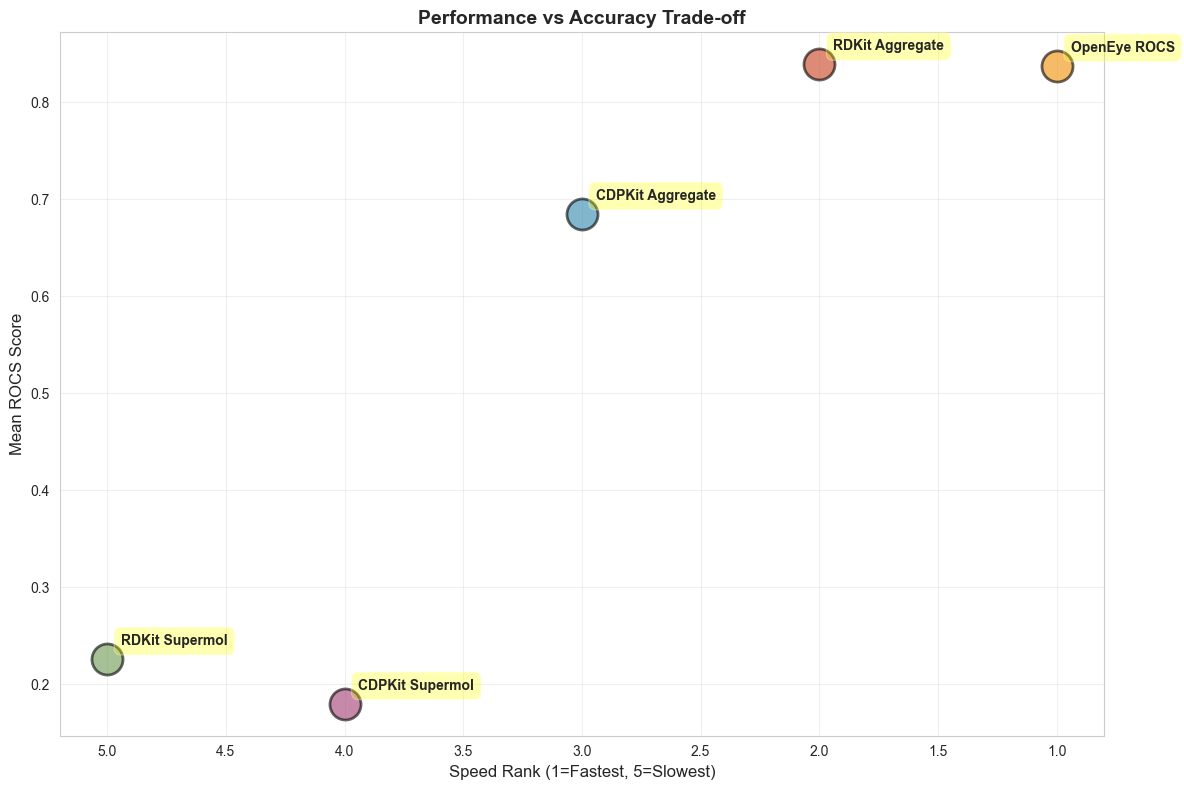


NOTE: Speed rankings are approximate and should be measured empirically for your specific hardware.


In [18]:
# Performance vs Accuracy trade-off analysis
# Manually input approximate timing data (would need to be measured separately)
performance_data = {
    'CDPKit Aggregate': {'speed_rank': 3, 'accuracy_rank': 2},
    'CDPKit Supermol': {'speed_rank': 4, 'accuracy_rank': 1},
    'OpenEye ROCS': {'speed_rank': 1, 'accuracy_rank': 1},
    'RDKit Aggregate': {'speed_rank': 2, 'accuracy_rank': 3},
    'RDKit Supermol': {'speed_rank': 5, 'accuracy_rank': 3}
}

# Add actual ROCS scores to performance data
for row in stats_data:
    label = row['Implementation']
    if label in performance_data:
        performance_data[label]['rocs_mean'] = row['ROCS Mean']
        performance_data[label]['rocs_max'] = row['ROCS Max']

perf_df = pd.DataFrame.from_dict(performance_data, orient='index').reset_index()
perf_df.columns = ['Implementation', 'Speed Rank', 'Accuracy Rank', 'ROCS Mean', 'ROCS Max']

plt.figure(figsize=(12, 8))
colors_list = [implementations[k]['color'] for k in implementations.keys()]

for idx, row in perf_df.iterrows():
    plt.scatter(row['Speed Rank'], row['ROCS Mean'], 
               s=500, c=[colors_list[idx]], alpha=0.6, 
               edgecolors='black', linewidth=2)
    plt.annotate(row['Implementation'], 
                (row['Speed Rank'], row['ROCS Mean']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))

plt.xlabel('Speed Rank (1=Fastest, 5=Slowest)', fontsize=12)
plt.ylabel('Mean ROCS Score', fontsize=12)
plt.title('Performance vs Accuracy Trade-off', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()  # Invert so fastest is on right
plt.tight_layout()
plt.show()

print("\nNOTE: Speed rankings are approximate and should be measured empirically for your specific hardware.")

## Summary and Recommendations

Based on the analysis above, here are key findings:

### Implementation Comparison:
1. **OpenEye ROCS**: Highest accuracy, fastest performance (requires license)
2. **CDPKit Supermol**: Best open-source accuracy, moderate speed
3. **CDPKit Aggregate**: Good balance of speed and accuracy (open-source)
4. **RDKit Aggregate**: Fast open-source option, good for prototyping
5. **RDKit Supermol**: Slower but competitive open-source alternative

### Use Case Recommendations:
- **Production/High-throughput**: OpenEye ROCS (if license available)
- **Research/High accuracy**: CDPKit Supermol or OpenEye ROCS
- **Development/Prototyping**: RDKit Aggregate
- **No license required**: CDPKit Aggregate (best balance)

### Key Metrics:
- Review the statistical comparison table above for detailed performance metrics
- Check convergence analysis for training efficiency
- Examine t-SNE plots for chemical space coverage
- Inspect top molecules for quality assessment